# Random Forest

### Table of contents
0. [Introduction](#0.-Introduction)
1. [A tiny dataset, by hand](#1.-A-tiny-dataset,-by-hand)
2. [Setup](#2.-Setup)
3. [A quick look at the data](#3.-A-quick-look-at-the-data)
4. [Random Forest](#4.-Random-Forest)
5. [Summary](#5.-Summary)

## 0. Introduction

Week 4's three classifiers each had a limit: Logistic Regression (linear only), KNN (slow), Decision Tree (unstable). This week asks two questions: what if we combine many models instead of one (Random Forest, Ensemble Learning)? And what if we approach the boundary differently (SVM, Naive Bayes)?

New dataset too: handwritten digits (`load_digits`), 10 classes instead of 2, and no model-fitting code needs to change for that.

This is notebook 1 of 5 for the week:
1. Random Forest (this one)
2. Ensemble Learning: Bagging and Boosting
3. Support Vector Machines
4. Naive Bayes
5. Comparing all eight models, summary, exercises

## 1. A tiny dataset, by hand

12 points, two classes, one of them mislabeled. Bootstrap it 3 times and fit a decision stump to each.

In [1]:
import numpy as np

X_bag_toy = np.array([
    [1.0, 1.0], [1.2, 1.5], [0.8, 1.2], [1.5, 0.8], [1.1, 1.8], [1.3, 1.1],
    [4.0, 4.0], [4.2, 3.8], [3.8, 4.2], [4.5, 3.5], [3.5, 4.5], [1.4, 1.4],
])
y_bag_toy = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
query = np.array([[1.3, 1.3]])

The last point, `[1.4, 1.4]`, sits with the class-0 cluster but is labeled 1: noise a single tree can chase.

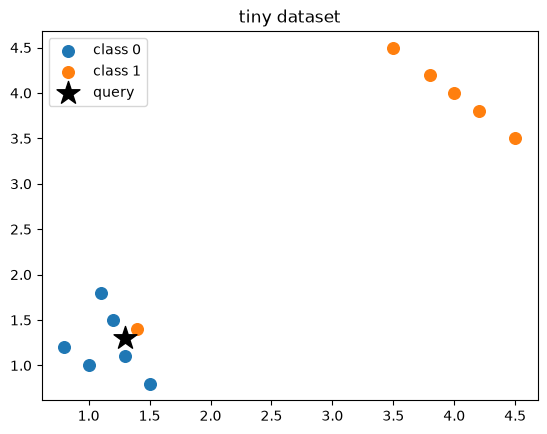

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X_bag_toy[y_bag_toy == 0, 0], X_bag_toy[y_bag_toy == 0, 1], label="class 0", s=70)
plt.scatter(X_bag_toy[y_bag_toy == 1, 0], X_bag_toy[y_bag_toy == 1, 1], label="class 1", s=70)
plt.scatter(*query[0], marker="*", s=300, color="black", label="query")
plt.legend()
plt.title("tiny dataset")
plt.show()

Bootstrap 3 samples (draw 12 points with replacement) and fit a decision stump to each:

In [3]:
from sklearn.tree import DecisionTreeClassifier

rng = np.random.default_rng(7)
stump_preds = []
for _ in range(3):
    idx = rng.integers(0, len(X_bag_toy), len(X_bag_toy))
    stump = DecisionTreeClassifier(max_depth=1, random_state=42).fit(X_bag_toy[idx], y_bag_toy[idx])
    stump_preds.append(stump.predict(query)[0])
stump_preds

[np.int64(0), np.int64(0), np.int64(1)]

Two stumps say 0, one says 1, fooled by the mislabeled point in its bootstrap draw. Majority vote wins:

In [4]:
np.bincount(stump_preds).argmax()

np.int64(0)

Confirm with a real forest: enough trees that the mislabeled point only fools a handful, not the majority.

In [5]:
from sklearn.ensemble import RandomForestClassifier

forest_toy = RandomForestClassifier(n_estimators=101, random_state=42).fit(X_bag_toy, y_bag_toy)
forest_toy.predict(query), forest_toy.predict_proba(query)

(array([0]), array([[0.89108911, 0.10891089]]))

90 of 101 trees vote class 0. `predict_proba` on a forest is literally the vote share: bag the data, grow a tree per bag, vote.

## 2. Setup

`load_digits`: 1,797 handwritten digit images, 8x8 pixels flattened to 64 features. Split with `stratify=y`, like week 4.

In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

data = load_digits(as_frame=True)
df = data.frame
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], " | Test size:", X_test.shape[0])

Train size: 1437  | Test size: 360


And a synthetic 2D dataset for boundary pictures: digits are 64-D and can't be plotted directly, so `make_moons` stands in.

In [7]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], alpha=0.35)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="white", linewidths=0.6, s=26)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

## 3. A quick look at the data

Before touching any model: this is a new dataset, and understanding it properly is the boring-but-important step that's easy to skip. Worth doing right, once.

### 3.1 Shape and data quality

In [8]:
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (1797, 65)
Missing values: 0
Duplicate rows: 0


In [9]:
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


Each row is one image: 64 pixel columns (`pixel_0_0` through `pixel_7_7`, intensities 0 to 16) plus the `target` digit. No missing values, no duplicates, but a wall of numbers like this is hard to read as an image yet.

In [10]:
X.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
pixel_0_0,0.000000,0.000000,0.0,0.0
pixel_0_1,0.303840,0.907192,0.0,8.0
pixel_0_2,5.204786,4.754826,0.0,16.0
pixel_0_3,11.835838,4.248842,0.0,16.0
pixel_0_4,11.848080,4.287388,0.0,16.0
pixel_0_5,5.781859,5.666418,0.0,16.0
pixel_0_6,1.362270,3.325775,0.0,16.0
pixel_0_7,0.129661,1.037383,0.0,15.0
pixel_1_0,0.005565,0.094222,0.0,2.0
pixel_1_1,1.993879,3.196160,0.0,16.0


Already a hint here too: `pixel_0_0` has `mean=0` and `std=0`. Some pixels never vary at all.

### 3.2 How is an image turned into numbers?

Every row above is really a grid of 64 numbers, pixel intensities from 0 (white) to 16 (black), read left to right, top to bottom. Same picture, with the actual numbers written on top:

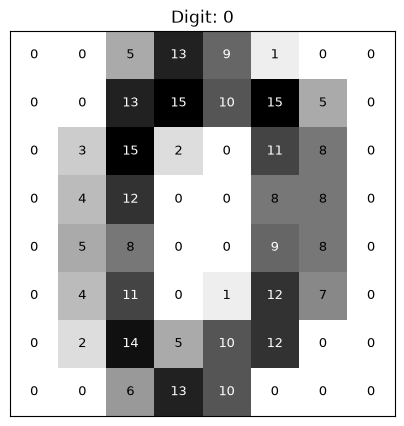

The exact same 64 numbers, flattened into one row:
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [11]:
sample_idx = 0
sample_image = data.images[sample_idx]

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(sample_image, cmap="gray_r")
for row in range(8):
    for col in range(8):
        value = int(sample_image[row, col])
        ax.text(col, row, value, ha="center", va="center",
                color="white" if value > 8 else "black", fontsize=9)
ax.set_title(f"Digit: {y[sample_idx]}")
ax.set_xticks([]); ax.set_yticks([])
plt.show()

print("The exact same 64 numbers, flattened into one row:")
print(X.iloc[sample_idx].values)

That flattened row is `pixel_0_0, pixel_0_1, ..., pixel_7_7` from `df.head()` above, for this one image. No separate "image" data type involved: `RandomForestClassifier` (and every other model this week) just sees 64 plain numbers per row, same as any other tabular feature.

### 3.3 Class balance

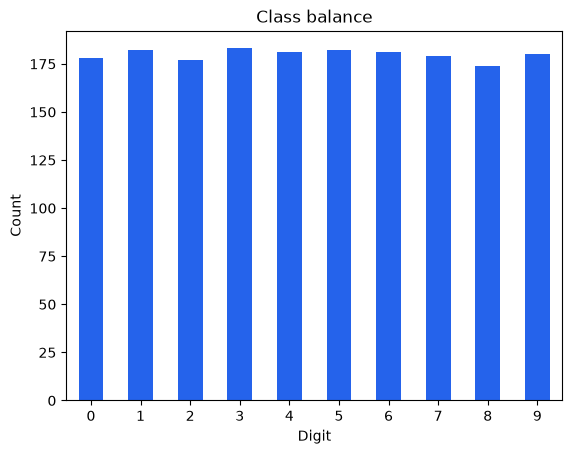

In [12]:
df["target"].value_counts().sort_index().plot(kind="bar", color="#2563EB")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Class balance")
plt.xticks(rotation=0)
plt.show()

Balanced, about 180 examples per digit. Unlike last week's imbalanced example, accuracy alone won't mislead here.

### 3.4 A closer look at the images

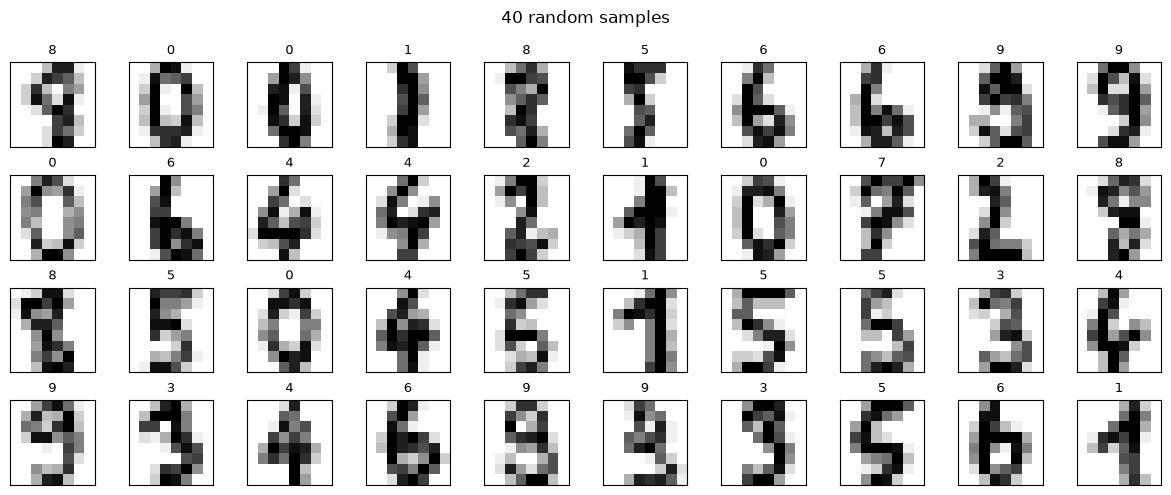

In [13]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X), size=40, replace=False)

fig, axes = plt.subplots(4, 10, figsize=(12, 5))
for idx, ax in zip(sample_idx, axes.flat):
    ax.imshow(data.images[idx], cmap="gray_r")
    ax.set_title(str(y[idx]), fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("40 random samples")
plt.tight_layout()
plt.show()

Real handwriting: same digit, many shapes. Worth looking closer at two that are often confused:

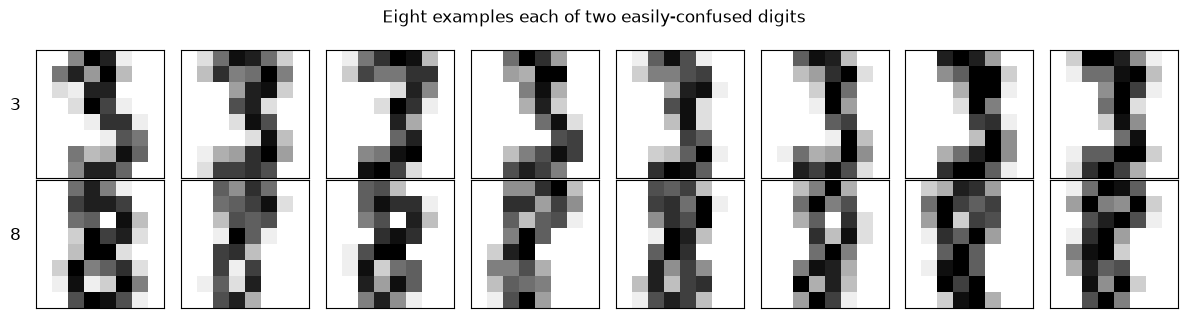

In [14]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for col, idx in enumerate(np.where(y == 3)[0][:8]):
    axes[0, col].imshow(data.images[idx], cmap="gray_r")
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
for col, idx in enumerate(np.where(y == 8)[0][:8]):
    axes[1, col].imshow(data.images[idx], cmap="gray_r")
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])
axes[0, 0].set_ylabel("3", fontsize=12, rotation=0, labelpad=15)
axes[1, 0].set_ylabel("8", fontsize=12, rotation=0, labelpad=15)
plt.suptitle("Eight examples each of two easily-confused digits")
plt.tight_layout()
plt.show()

3 and 8 share a lot of structure, and some examples are genuinely ambiguous even to a human eye. Worth remembering later, when a model's mistakes look "dumb": sometimes the data itself is hard.

### 3.5 The "average" digit, per class

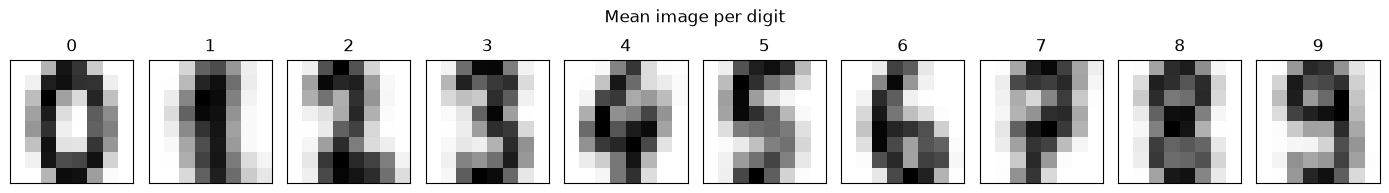

In [15]:
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for digit, ax in enumerate(axes.flat):
    mean_image = data.images[y == digit].mean(axis=0)
    ax.imshow(mean_image, cmap="gray_r")
    ax.set_title(str(digit))
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Mean image per digit")
plt.tight_layout()
plt.show()

Averaged over ~180 examples each, every digit still stays recognizable: a good sign this dataset is learnable.

### 3.6 Which pixels carry information?

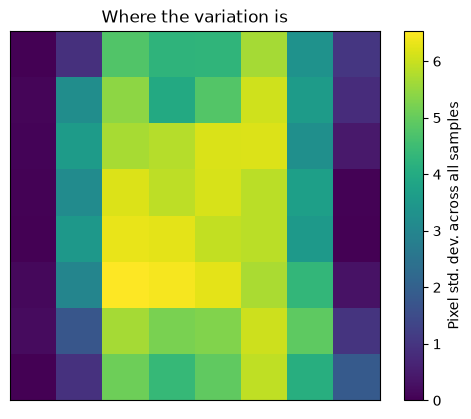

In [16]:
pixel_std = X.std().values.reshape(8, 8)

plt.imshow(pixel_std, cmap="viridis")
plt.colorbar(label="Pixel std. dev. across all samples")
plt.title("Where the variation is")
plt.xticks([]); plt.yticks([])
plt.show()

The corners, almost always blank like `pixel_0_0` above, carry almost no signal. The center, where strokes happen, does nearly all the work. Keep this picture in mind: section 4.4's Random Forest feature importance map will come back to it.

## 4. Random Forest

A single tree is unstable: small data changes reshape it. Random Forest's fix: train many trees on random samples and random feature subsets, then vote. Baseline first:

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(max_depth=8, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print(f"Decision Tree (max_depth=8) test accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")

Decision Tree (max_depth=8) test accuracy: 0.8083


In [18]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, random_state=42)
forest.fit(X_train, y_train)

y_pred_forest = forest.predict(X_test)
print(f"Decision Tree     test accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Random Forest     test accuracy: {accuracy_score(y_test, y_pred_forest):.4f}")

Decision Tree     test accuracy: 0.8083
Random Forest     test accuracy: 0.9639


Individually noisy trees, but their mistakes don't agree, so voting cancels much of it out:

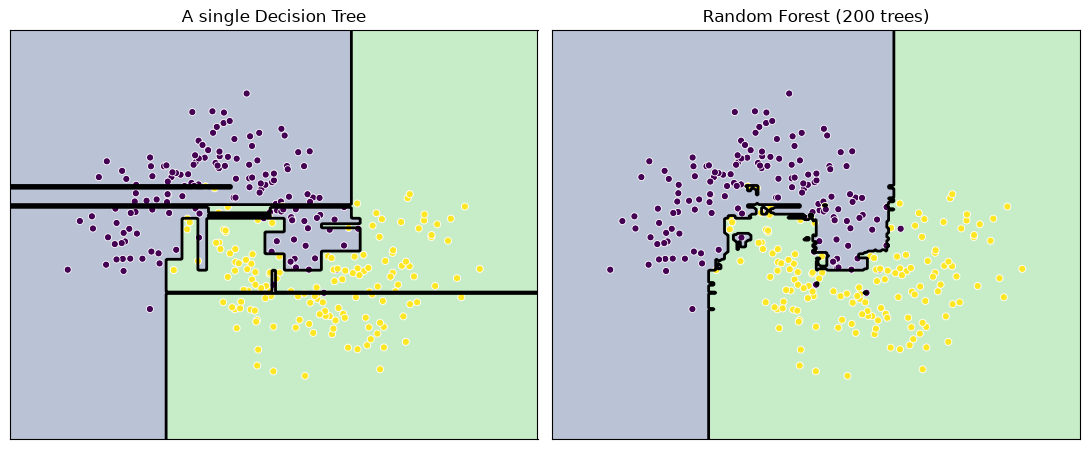

In [19]:
tree_moons = DecisionTreeClassifier(random_state=42).fit(X_moons, y_moons)
forest_moons = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_moons, y_moons)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
plot_boundary(axes[0], tree_moons, X_moons, y_moons, "A single Decision Tree")
plot_boundary(axes[1], forest_moons, X_moons, y_moons, "Random Forest (200 trees)")
plt.tight_layout()
plt.show()

### 4.1 Seeing inside the forest

A Random Forest is genuinely just many Decision Trees. Two ways to see that directly: their individual boundaries, and an actual tree structure.

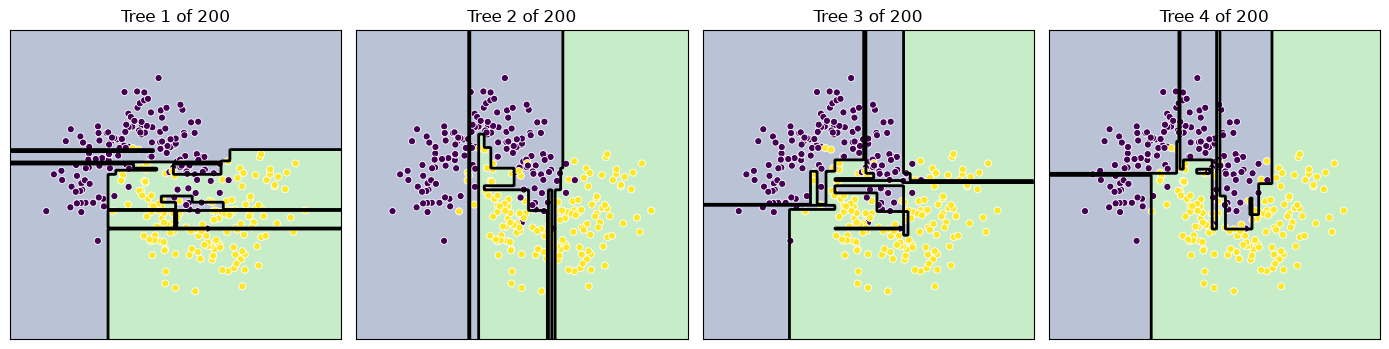

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for i, ax in enumerate(axes.flat):
    plot_boundary(ax, forest_moons.estimators_[i], X_moons, y_moons, f"Tree {i + 1} of 200")
plt.tight_layout()
plt.show()

Four trees from the same forest, four different boundaries: each saw a different bootstrap sample and a different random subset of features at every split. None of them alone is great; averaged together (the picture just above), they're much better.

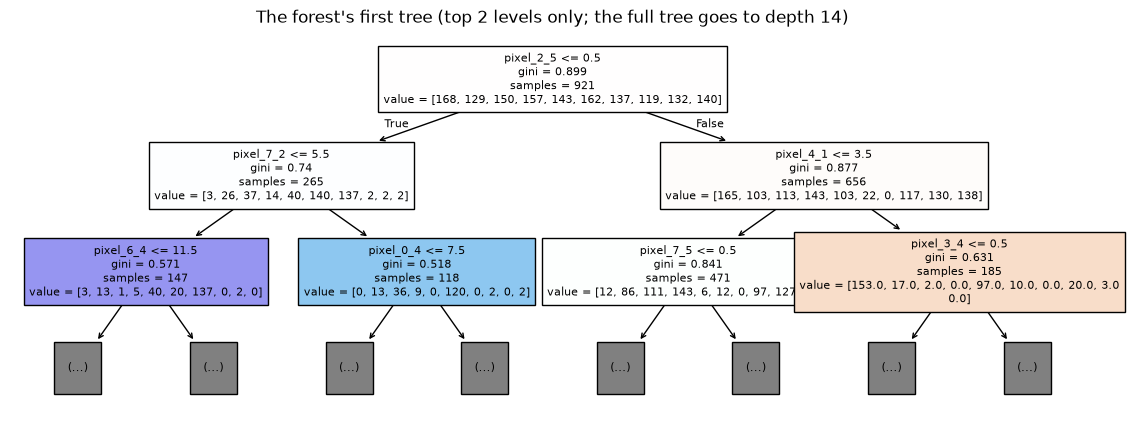

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 5))
plot_tree(forest.estimators_[0], max_depth=2, feature_names=list(X.columns), filled=True, fontsize=8)
plt.title("The forest's first tree (top 2 levels only; the full tree goes to depth 14)")
plt.show()

Same `DecisionTreeClassifier` from week 4, same Gini-impurity splits, just grown on a bootstrap sample with a random subset of features considered at each split, and left unpruned.

### 4.2 How many trees is enough?

`n_estimators` is close to a free lunch: more trees rarely hurts, but gains flatten out.

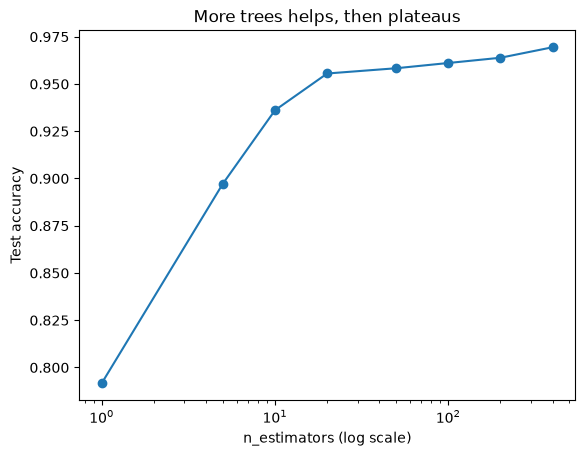

In [22]:
n_trees_list = [1, 5, 10, 20, 50, 100, 200, 400]
test_acc_rf = [
    accuracy_score(y_test, RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train, y_train).predict(X_test))
    for n in n_trees_list
]

plt.plot(n_trees_list, test_acc_rf, marker="o")
plt.xscale("log")
plt.xlabel("n_estimators (log scale)")
plt.ylabel("Test accuracy")
plt.title("More trees helps, then plateaus")
plt.show()

### 4.3 Other hyperparameters worth knowing

`n_estimators` isn't the only knob:

- **`max_features`**: how many features each split can consider (`"sqrt"` by default). This is the forest's *second* source of randomness, alongside bootstrap sampling, and the main reason its trees end up different from each other.
- **`max_depth`, `min_samples_split`, `min_samples_leaf`**: the same regularization levers from week 4's Decision Tree, applied to every tree in the forest.
- **`bootstrap`**: whether each tree trains on a random sample at all (`True` by default). Turning it off removes half of what makes a Random Forest "random."

A quick look at that second source of randomness: what happens if every split can see all 64 features instead of a random subset?

In [23]:
forest_all_features = RandomForestClassifier(n_estimators=200, max_features=None, random_state=42)
forest_all_features.fit(X_train, y_train)
y_pred_all_features = forest_all_features.predict(X_test)

print(f"max_features=\"sqrt\" (default) test accuracy: {accuracy_score(y_test, y_pred_forest):.4f}")
print(f"max_features=None (all features) test accuracy: {accuracy_score(y_test, y_pred_all_features):.4f}")

max_features="sqrt" (default) test accuracy: 0.9639
max_features=None (all features) test accuracy: 0.9306


Noticeably worse with `max_features=None`: every tree tends to split on the same handful of strongest pixels first, so the trees end up more correlated with each other. Bagging's random samples alone aren't enough; the random feature subsets are doing real work.

### 4.4 Feature importance, visualized

A forest can also rank **feature importance** across all its trees. Here each feature is a pixel, so importances reshape into an 8x8 image:

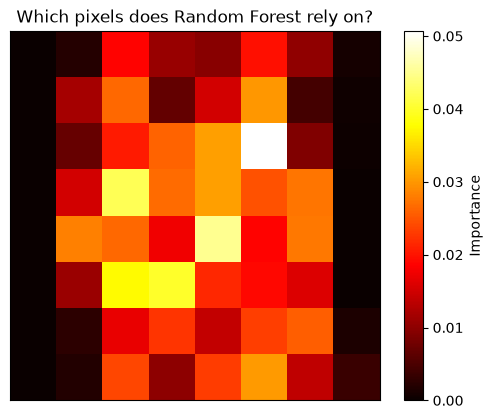

In [24]:
importances = forest.feature_importances_.reshape(8, 8)

plt.figure()
plt.imshow(importances, cmap="hot")
plt.colorbar(label="Importance")
plt.title("Which pixels does Random Forest rely on?")
plt.xticks([]); plt.yticks([])
plt.show()

Where do these numbers come from? Each tree computes its own version: how much every feature's splits reduced impurity (the same Gini impurity from week 4), summed across all its splits and normalized to add up to 1. The forest's picture above is just the average of that computation across all 200 trees. One tree alone, for comparison:

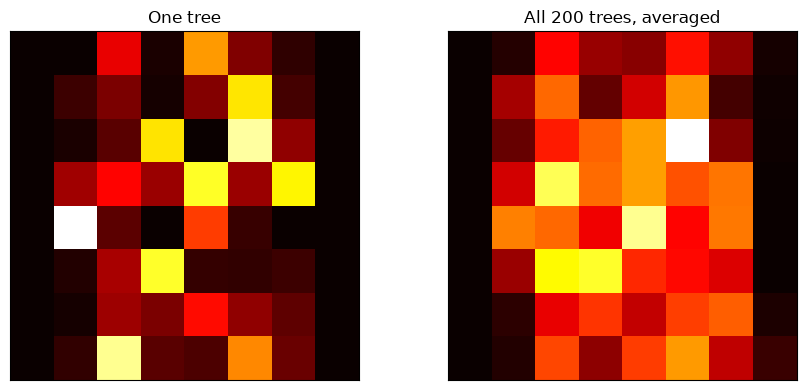

In [25]:
first_tree_importances = forest.estimators_[0].feature_importances_.reshape(8, 8)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(first_tree_importances, cmap="hot")
axes[0].set_title("One tree")
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].imshow(importances, cmap="hot")
axes[1].set_title("All 200 trees, averaged")
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout()
plt.show()

One tree alone is patchy: it only ever saw a random subset of features at each split. Averaged over 200 trees, it smooths into something far more stable, the same bagging idea from earlier in this notebook, just applied to this number instead of to predictions.

This looks a lot like section 3.6's variance map. Are they actually measuring the same thing?

In [26]:
correlation = np.corrcoef(pixel_std.flatten(), importances.flatten())[0, 1]
print(f"Correlation between pixel variance and Random Forest importance: {correlation:.2f}")

Correlation between pixel variance and Random Forest importance: 0.85


Strongly related, as that number shows, but not identical. A pixel that never varies obviously can't help any model, so the two agree on the obvious dead corners. But variance alone doesn't know the actual digit labels the way importance does, so they can disagree on the subtler pixels: importance is the more targeted number of the two, and the one that actually reflects what the model relies on.

## 5. Summary

- No missing values or duplicates, classes are balanced, and an image is really just a flat vector of pixel intensities to every model here, nothing more exotic.
- Random Forest trains many trees on random samples and random feature subsets, then votes (**Bagging**), more stable than any one tree, and its individual trees are visibly diverse.
- `n_estimators`: more trees rarely hurts, but gains flatten out. `max_features` is the forest's other source of randomness: removing it costs real accuracy.
- Feature importance averages each tree's own impurity-based importance across the forest, producing a picture strongly related to, but not identical to, raw pixel variance.
- No code changes needed for 10 classes instead of 2.

Notebook 2: the general idea behind Random Forest, plus a second family: Boosting.